In [1]:
import numpy as np
import pylab as plt
import pyccl as ccl
import math

import sys
sys.path.append('/Users/sergipadilla/IFAE/CS_Fisher')
from src import load_config, fisher_matrix, redshift_distributions, IO, names_to_latex, compute_Omega_nu, sergi_functions
from itertools import pairwise

# plots are rendered inline within the notebook
%matplotlib inline 

In [2]:
import importlib
importlib.reload(sergi_functions)

<module 'src.sergi_functions' from '/Users/sergipadilla/IFAE/CS_Fisher/src/sergi_functions.py'>

## Main code

In [3]:
config = load_config('../configs/config_neutrinos.yaml')

In [4]:
print(f'Running fisher analysis for {config.name}.')

# Load the cosmology
ccl_cosmo_params = dict(zip(config.cosmology.keys(), config.cosmology.values()))

if 'Omega_m' in ccl_cosmo_params.keys():
    # Sergi
    # Substract Omega_nu (in therms of variables from cosmology) --> function defined in src/utils.py
    #ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b']
    ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b'] - compute_Omega_nu(config.cosmology.m_nu, config.cosmology.h, config.neutrinos.mass_split)
    ccl_cosmo_params.pop('Omega_m')

#Sergi
# Add mass_split to cosmology inputs
cosmo = ccl.Cosmology(**ccl_cosmo_params,
                      mass_split = config.neutrinos.mass_split,
                      matter_power_spectrum='camb',
                       extra_parameters = {"camb": config.baryons_dict})

# ell binning setup
ell_bins = np.geomspace(config.ell_binning.cosmic_shear.bin_start,
                            config.ell_binning.cosmic_shear.bin_end,
                            config.ell_binning.cosmic_shear.N_bins+1)
ell_bins = ell_bins[
    (ell_bins >= config.ell_binning.cosmic_shear.ell_min) &
    (ell_bins <= config.ell_binning.cosmic_shear.ell_max)
    ].astype(int)
ell_arr = np.array([(a + b) / 2 for a, b in pairwise(ell_bins)]).astype(int)
Delta_ell = np.array([b - a for a, b in pairwise(ell_bins)])

# Define the forecasting setup
sigma_e = config.forecast.e_rms
N_z_bins = config.redshift_distributions.sources.N_z_bins
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                    config.forecast.N_z_values)
nz_arr, zbin_edges = (
    redshift_distributions.get_redshift_distributions(
        z_arr, N_z_bins,
        config.redshift_distributions.sources.z0,
        config.redshift_distributions.sources.a,
        config.redshift_distributions.sources.sigma_z))

# Define the fisher matrix setup
#Sergi
# Add mass split key and value to cosmo_params
cosmo_params = {'name': list(config.cosmology.keys()),
                'fiducial': list(config.cosmology.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.cosmology.keys())],
                'latex': [names_to_latex(x) for x in config.cosmology.keys()],
                'mass_split': config.neutrinos.mass_split}
astro_params = {'name': list(config.IA.keys())+list(config.baryons.keys()),
                'fiducial': list(config.IA.values())+list(config.baryons.values()),
                'shift': [config.derivatives.step_size[x] for x in list(config.IA.keys())+list(config.baryons.keys())],
                'latex': [names_to_latex(x) for x in list(config.IA.keys())+list(config.baryons.keys())]}
redshift_params = {'name': [f'dz{i+1}' for i in range(N_z_bins)],
                   'fiducial': [0.] * N_z_bins,
                   'shift': [config.derivatives.step_size.delta_z] * N_z_bins,
                   'latex': [r'$\Delta z_{%i}$' % (i + 1) for i in range(N_z_bins)]}


# Compute the fisher matrix
print(f'Computing fisher matrix.')
fm = fisher_matrix(cosmo=cosmo, z=z_arr, dndz=nz_arr, ell=ell_arr,
                   sigma_e=sigma_e,
                   n_bar=config.redshift_distributions.sources.nbar,
                   fsky=config.forecast.fsky, Delta_ell=Delta_ell,
                   n_points=config.derivatives.stencil_points, cosmo_params=cosmo_params,
                   astro_params=astro_params, redshift_params=redshift_params)
# Add Gaussian photo-z priors
mean_z = np.trapz(nz_arr * z_arr, z_arr)
scale_z = config.redshift_distributions.sources.sigma_delta_z*(1+mean_z)
fm.add_prior(redshift_params['name'], scale_z)

print('Fisher matrix calculation finished.')



Running fisher analysis for neutrinos_1.1.
Computing fisher matrix.
Fisher matrix calculation finished.


## Compute Cell's with halo-model

In [5]:
#Un-windowed halo-model power spectras
pk_II, pk_GI = sergi_functions.get_pk_halomod(cosmo, 1.0)

#Windowed halo-model power spectras
pk_II_windowed, pk_GI_windowed = sergi_functions.get_pk_halomod_windowed(cosmo, 1.0) #, a1h=0

#Un-windowed C_ells
C_ell_unwindowed = sergi_functions.get_Cell_data_vector_halomod(cosmo,
                         z_arr, nz_arr,
                         pk_II, pk_GI,
                         ell_arr)
#Windowed C_ells
C_ell_windowed = sergi_functions.get_Cell_data_vector_halomod(cosmo,
                         z_arr, nz_arr,
                         pk_II_windowed, pk_GI_windowed,
                         ell_arr)

## Plotting Cell's

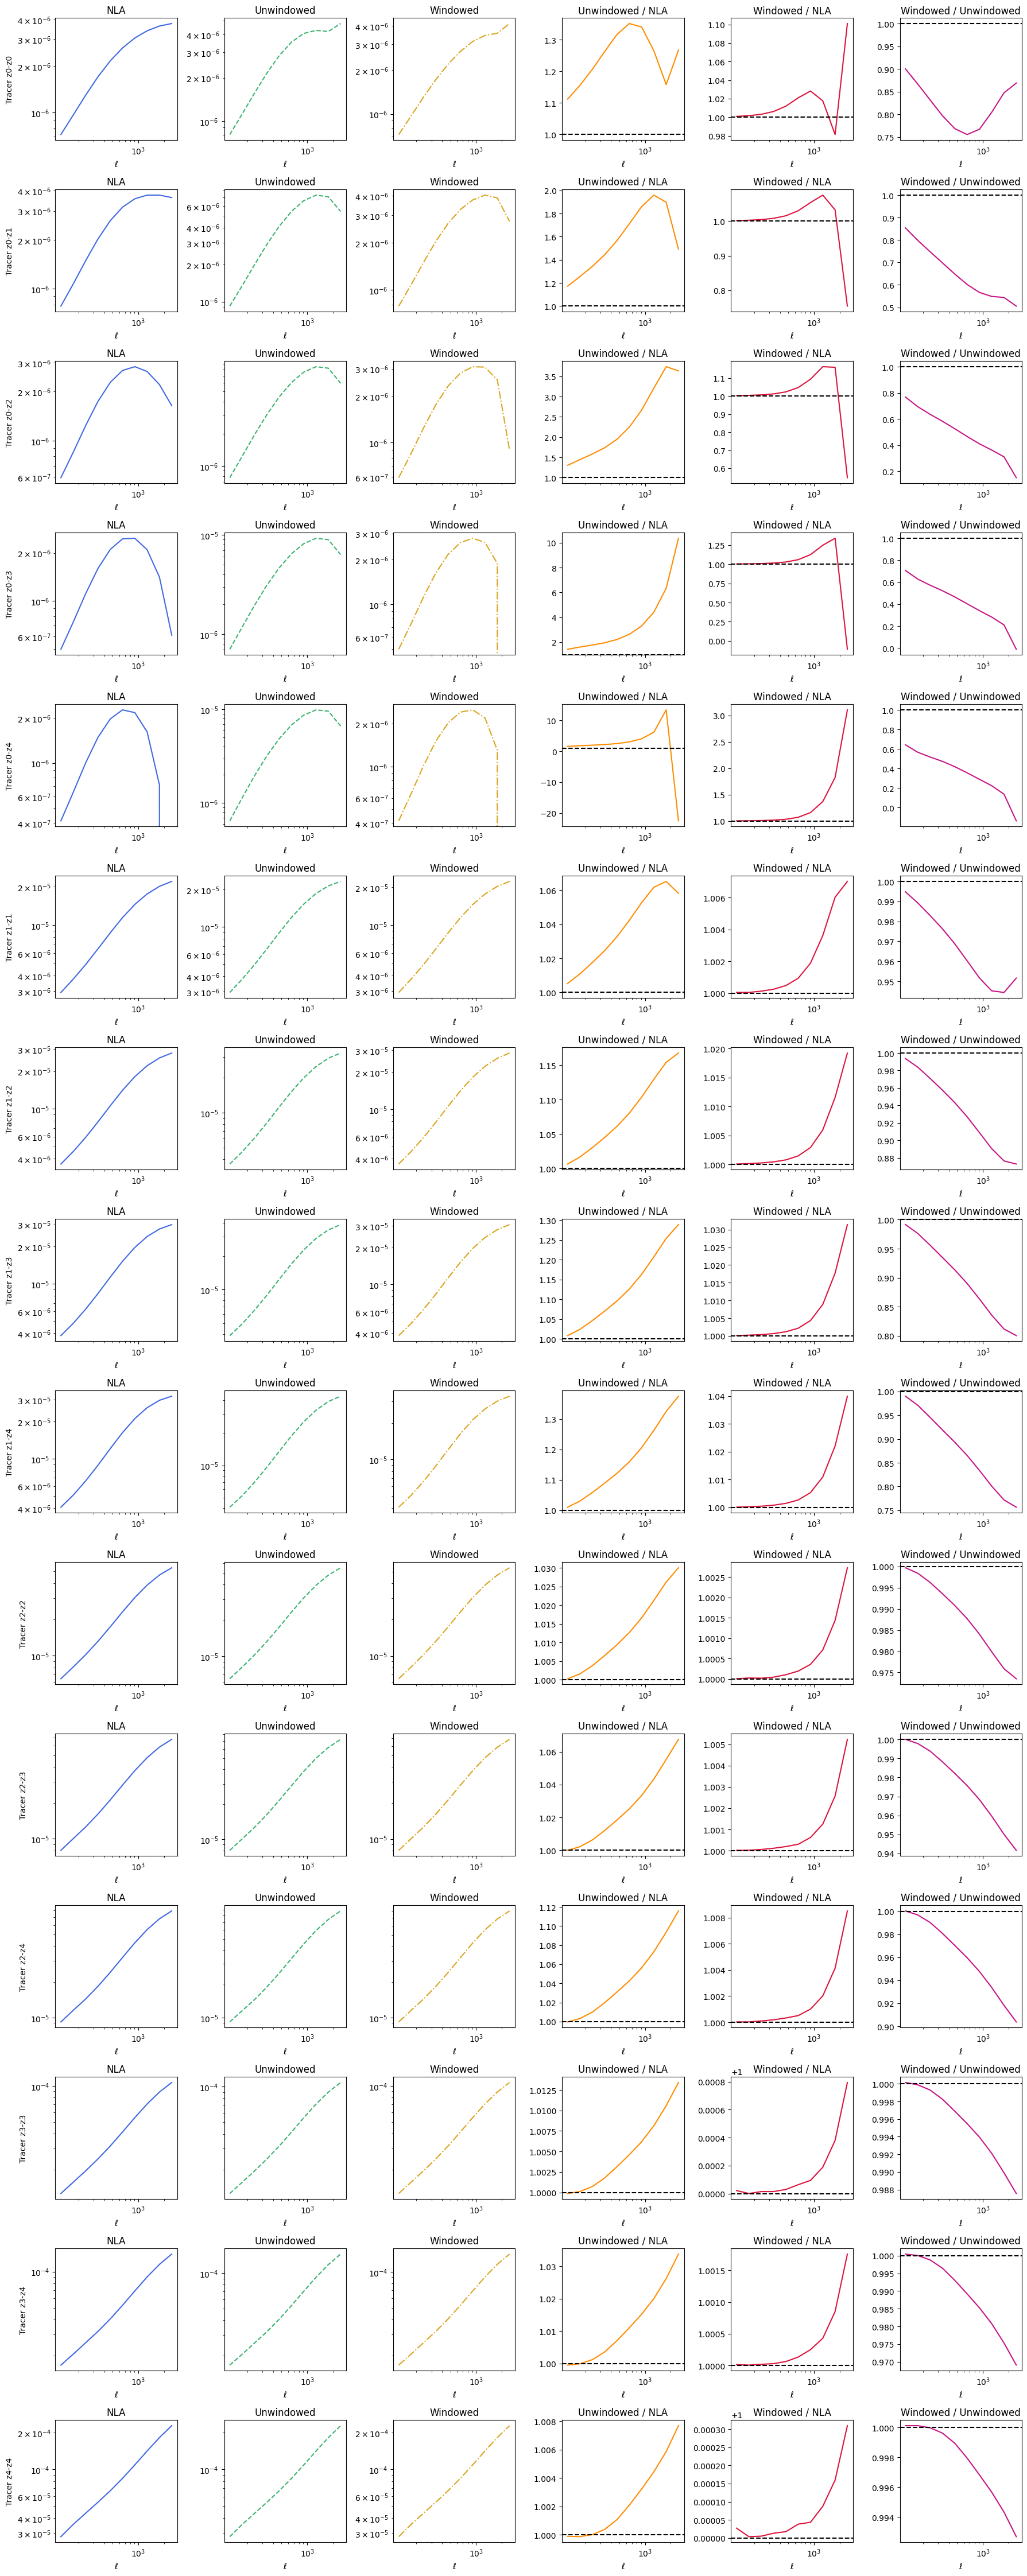

In [9]:
n_tracers = len(C_ell_unwindowed.keys())
ncols = 6  # NLA, unwindowed, windowed, unwindowed/NLA, windowed/NLA, windowed/unwindowed
nrows = n_tracers

c_ell_NLA = fm.C_ell

# Convert C_ell to Cl * l(l+1)/2pi
lfac = ell_arr * (ell_arr + 1) / (2 * np.pi)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 3 * nrows)) #figsize=(width, height) 3 in hight per plot

for idx, tracer in enumerate(C_ell_unwindowed.keys()):
    # Scale the C_ells for plotting
    cell_nla_scaled = c_ell_NLA[tracer] * lfac
    cell_unwindowed_scaled = C_ell_unwindowed[tracer] * lfac
    cell_windowed_scaled = C_ell_windowed[tracer] * lfac

    # First 3 plots: C_ells * l(l+1)/2pi
    axes[idx, 0].loglog(ell_arr, cell_nla_scaled, label='NLA', color='royalblue')
    axes[idx, 0].set_title('NLA')

    axes[idx, 1].loglog(ell_arr, cell_unwindowed_scaled, label='Unwindowed', linestyle='--', color='mediumseagreen')
    axes[idx, 1].set_title('Unwindowed')

    axes[idx, 2].loglog(ell_arr, cell_windowed_scaled, label='Windowed', linestyle='-.', color='goldenrod')
    axes[idx, 2].set_title('Windowed')

    # plot 4: unwindowed / NLA
    ratio1 = cell_unwindowed_scaled / cell_nla_scaled
    axes[idx, 3].semilogx(ell_arr, ratio1, color='darkorange')
    axes[idx, 3].axhline(1, color='k', linestyle='--')
    axes[idx, 3].set_title('Unwindowed / NLA')

    # plot 5: windowed / NLA
    ratio2 = cell_windowed_scaled / cell_nla_scaled
    axes[idx, 4].semilogx(ell_arr, ratio2, color='crimson')
    axes[idx, 4].axhline(1, color='k', linestyle='--')
    axes[idx, 4].set_title('Windowed / NLA')

    # plot 6: windowed / unwindowed
    ratio3 = cell_windowed_scaled / cell_unwindowed_scaled
    axes[idx, 5].semilogx(ell_arr, ratio3, color='mediumvioletred')
    axes[idx, 5].axhline(1, color='k', linestyle='--')
    axes[idx, 5].set_title('Windowed / Unwindowed')
    

    # Y-label per row
    for ax in axes[idx, :]:
        ax.set_xlabel(r"$\ell$") # write ell in x-axis in all plots per row
    axes[idx, 0].set_ylabel(f"Tracer {tracer}") # write zi-zj onlu in the 1st column for better visual

plt.tight_layout()
plt.show()

## Systematic Bias and Statistical error

In [10]:
# Compute bias vector for both "observed models"
B_unwindowed = sergi_functions.bias_vector(C_ell_unwindowed, fm.C_ell, fm.data_covariance, fm.d_C_ell)
B_windowed = sergi_functions.bias_vector(C_ell_windowed, fm.C_ell, fm.data_covariance, fm.d_C_ell)

# Compute the values of the bias for each parameters and store them in a vector
B_parameter_unwindowed = sergi_functions.bias_parameter(fm.fisher_matrix, B_unwindowed)
B_parameter_windowed = sergi_functions.bias_parameter(fm.fisher_matrix, B_windowed)

# Compute statistical error of the parameters varied aka standard deviation
sigma_vec = sergi_functions.standard_dev(fm.fisher_matrix)

In [12]:
import pandas as pd

data = pd.DataFrame({
    'Parameter': list(fm.parameters),
    'Fiducial value': list(fm.fiducial_parameters),
    'Systematic unwindowed': B_parameter_unwindowed,
    'Systematic windowed': B_parameter_windowed,
    'Statistical Error': sigma_vec,
    'Systematic unwindowed/Statistical': [sys/stat for sys, stat in zip(B_parameter_unwindowed, sigma_vec)],
    'Systematic windowed/Statistical': [sys/stat for sys, stat in zip(B_parameter_windowed, sigma_vec)]
})

#data.set_index('Parameter').T

# lambda creates a list with the same length as the number of columns, axis = 1 for rows, axis = 0 for columns,
# x is row of data frame in this case, x.name is name of row, if row name is the ratio we want
# it sets background colour to light green, otherwise '' (no special style)
styled_data = data.set_index('Parameter').T.style.apply(
    lambda x: ['background-color: #D5F5E3' if x.name == 'Systematic windowed/Statistical' else '' for _ in x],
    axis=1)

styled_data

Parameter,Omega_m,Omega_b,h,A_s,n_s,m_nu,A_IA,dz1,dz2,dz3,dz4,dz5
Fiducial value,0.315000,0.049000,0.674000,0.000000,0.965000,0.060000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Systematic unwindowed,0.035654,-0.033628,-0.804457,0.000000,0.437453,-0.856105,-0.431254,-0.008867,0.000998,0.005896,0.004368,-0.010158
Systematic windowed,0.001633,-0.000230,-0.048792,0.000000,0.037985,-0.146325,-0.014133,-0.000232,-0.000172,0.000291,0.000268,-0.000538
Statistical Error,0.011503,0.036732,0.239835,0.000000,0.092279,0.376987,0.021164,0.001777,0.001901,0.002143,0.002457,0.004671
Systematic unwindowed/Statistical,3.099443,-0.915511,-3.354210,3.964928,4.740555,-2.270912,-20.376461,-4.990226,0.524810,2.751420,1.777828,-2.174790
Systematic windowed/Statistical,0.141995,-0.006271,-0.203442,0.143845,0.411636,-0.388143,-0.667769,-0.130304,-0.090499,0.135695,0.109232,-0.115102


## Visualize parameter space

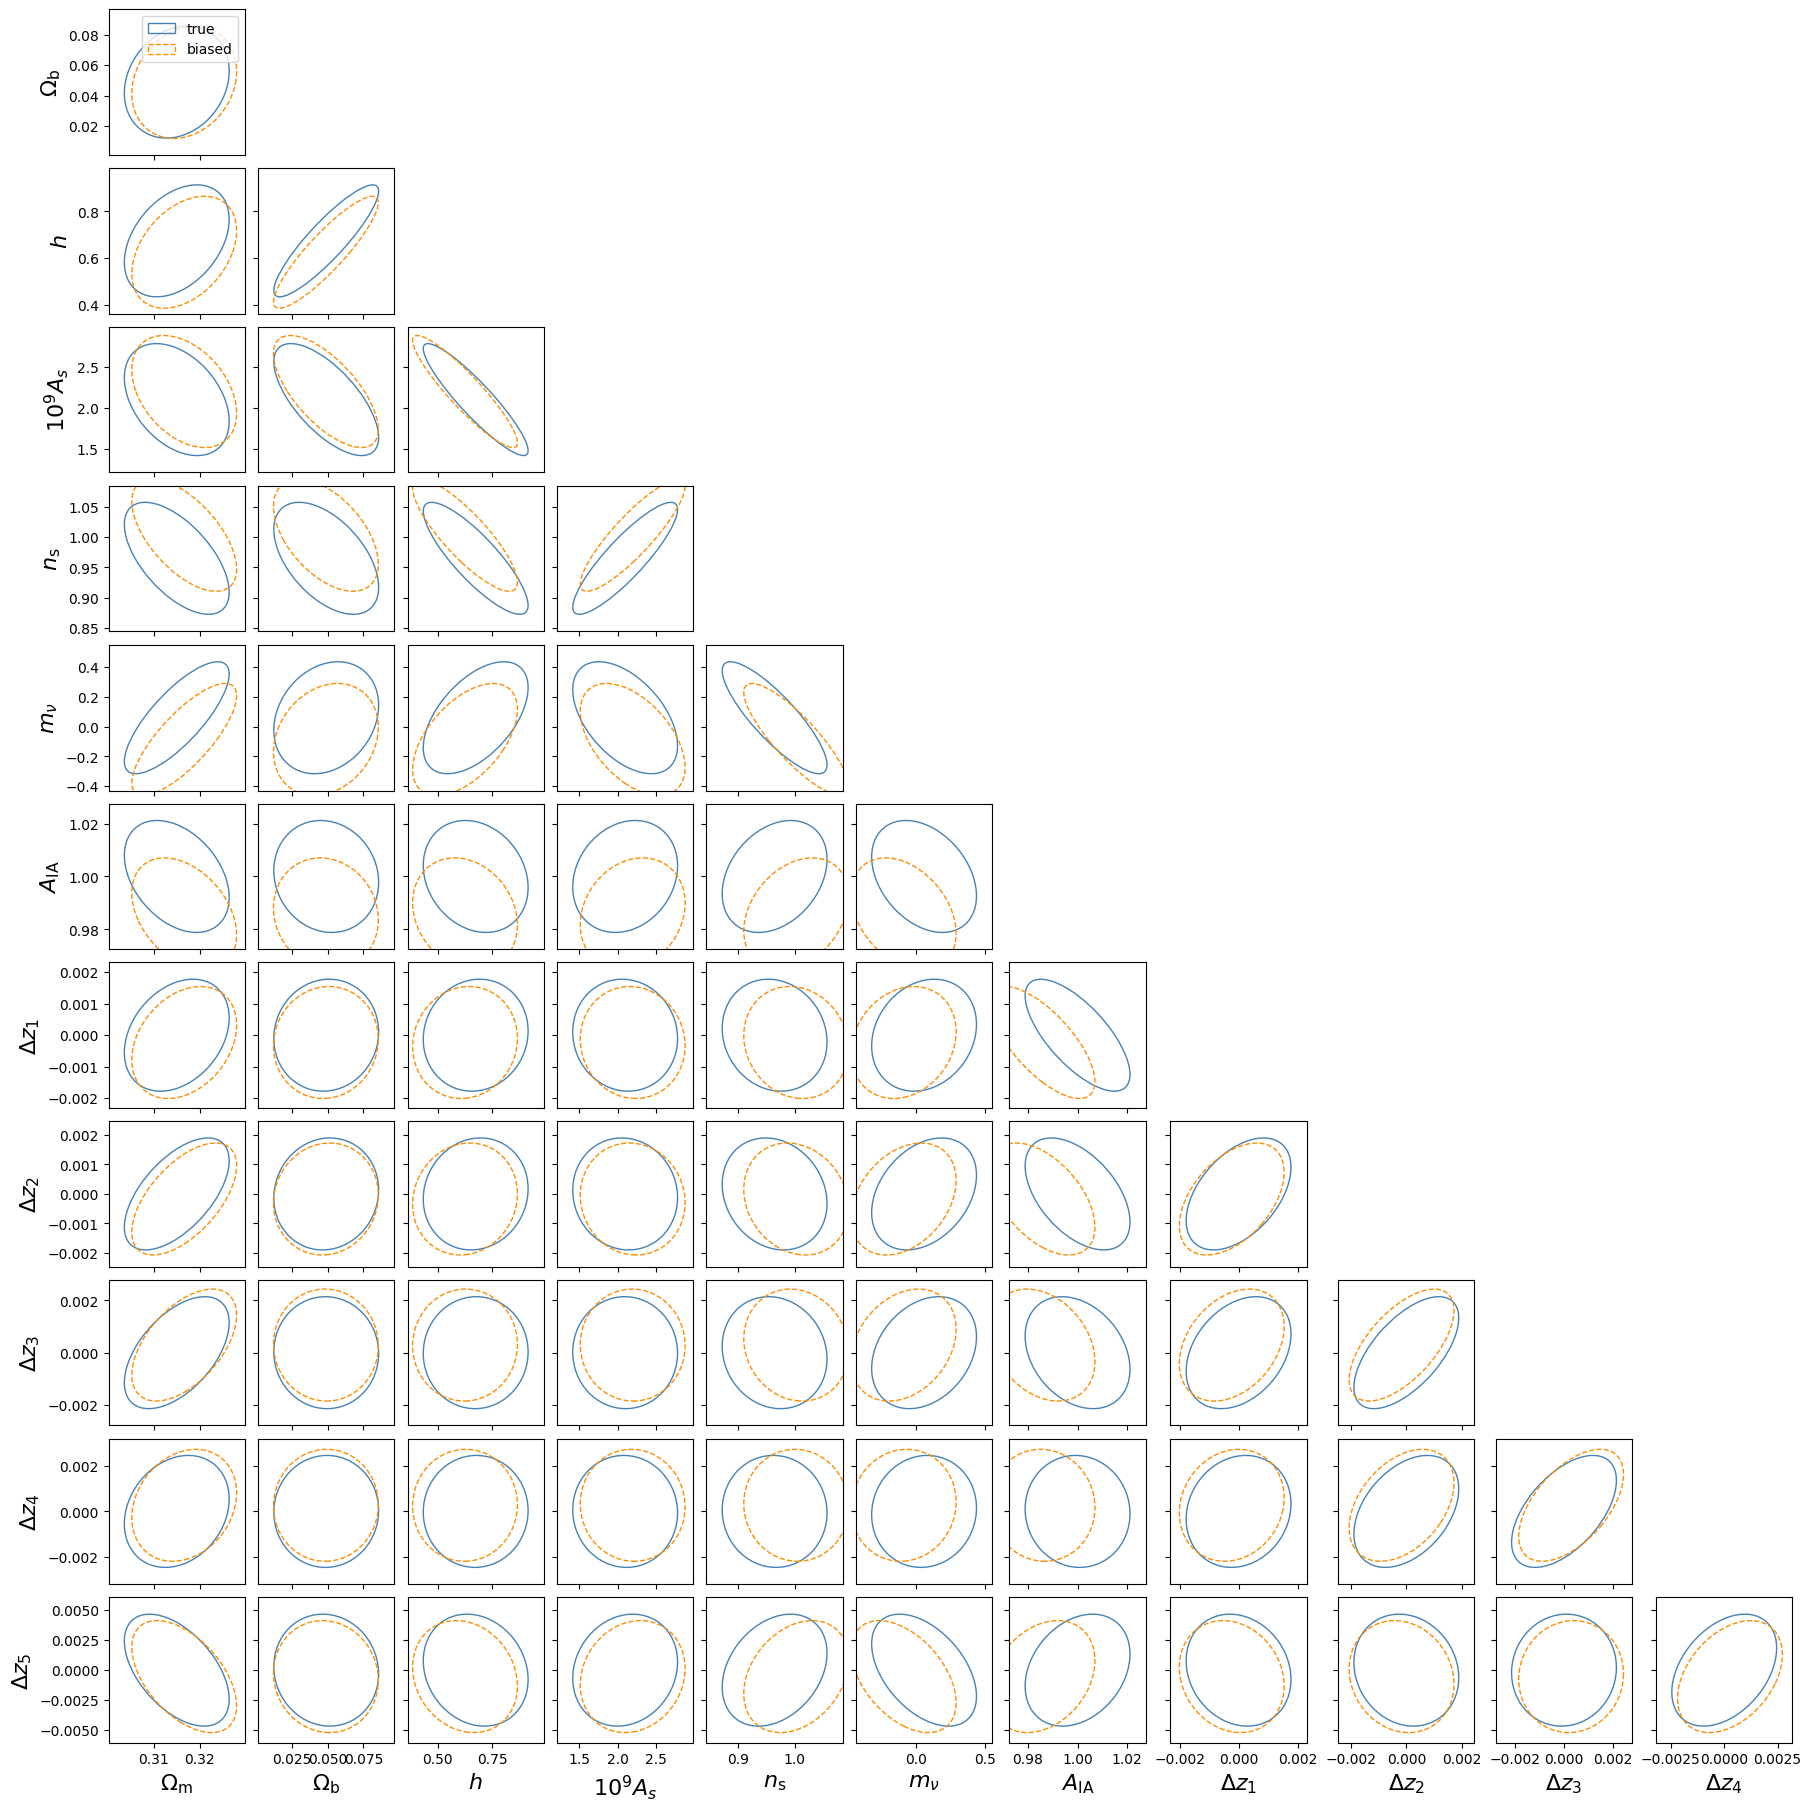

In [13]:
fm_m9 = fm.transform_A_s_to_m9A_s()
parameters = fm_m9.parameters
fig, axes = plt.subplots(len(parameters)-1, len(parameters)-1, figsize=(18,18),
                         sharex='col', sharey='row', layout='compressed', squeeze=False)
for p2i, param2 in enumerate(parameters[1:]): # row
    for p1i, param1 in enumerate(parameters[:-1]): # column
        ax = axes[p2i, p1i]
        if p1i>p2i:
            fig.delaxes(ax)
            continue
        else:

            param_pair = [param1, param2]
            
            # True ellipse
            ax, xlim, ylim, mu, latex = fm_m9.draw_covariance_ellipse(ax, param_pair,
                CL=0.393, color='steelblue', fill=False, ls='-', label = 'true')

            # find positions (index) of parameter 1 and 2 in parameter list 
            indx = np.where(np.in1d(fm_m9.parameters, param_pair))[0]

            # find fiducial parameter pairs and their respective biases
            mu_fid = fm_m9.fiducial_parameters[indx]
            biases = B_parameter_windowed[indx].copy()

            # if plotting A_s_9, we need to scale its bias
            for i, param in enumerate(param_pair):
                if param == 'A_s_9':
                    biases[i] *= 1e9
            
            # compute the biased center of the ellipse
            mu_biased = mu_fid + biases

            # Biased ellipse
            fm_m9.draw_covariance_ellipse(ax, param_pair, mu=mu_biased, CL=0.393, 
                                          color='darkorange', fill=False, ls='--', label = 'biased')
        
            ax.set_xlim([mu[0]-1.3*xlim, mu[0]+1.3*xlim])
            
            ax.set_ylim([mu[1]-1.3*ylim, mu[1]+1.3*ylim])

            if p1i == 0: # only plot label on first column
                ax.set_ylabel(f'{latex[1]}', fontsize=16)
                
            if p2i == len(parameters) -2: #only plot label on las row
                ax.set_xlabel(f'{latex[0]}', fontsize=16)
                
            if p2i == p1i ==0: # legend only on the first plot
                ax.legend(loc='upper right')            

## Understanding the physics

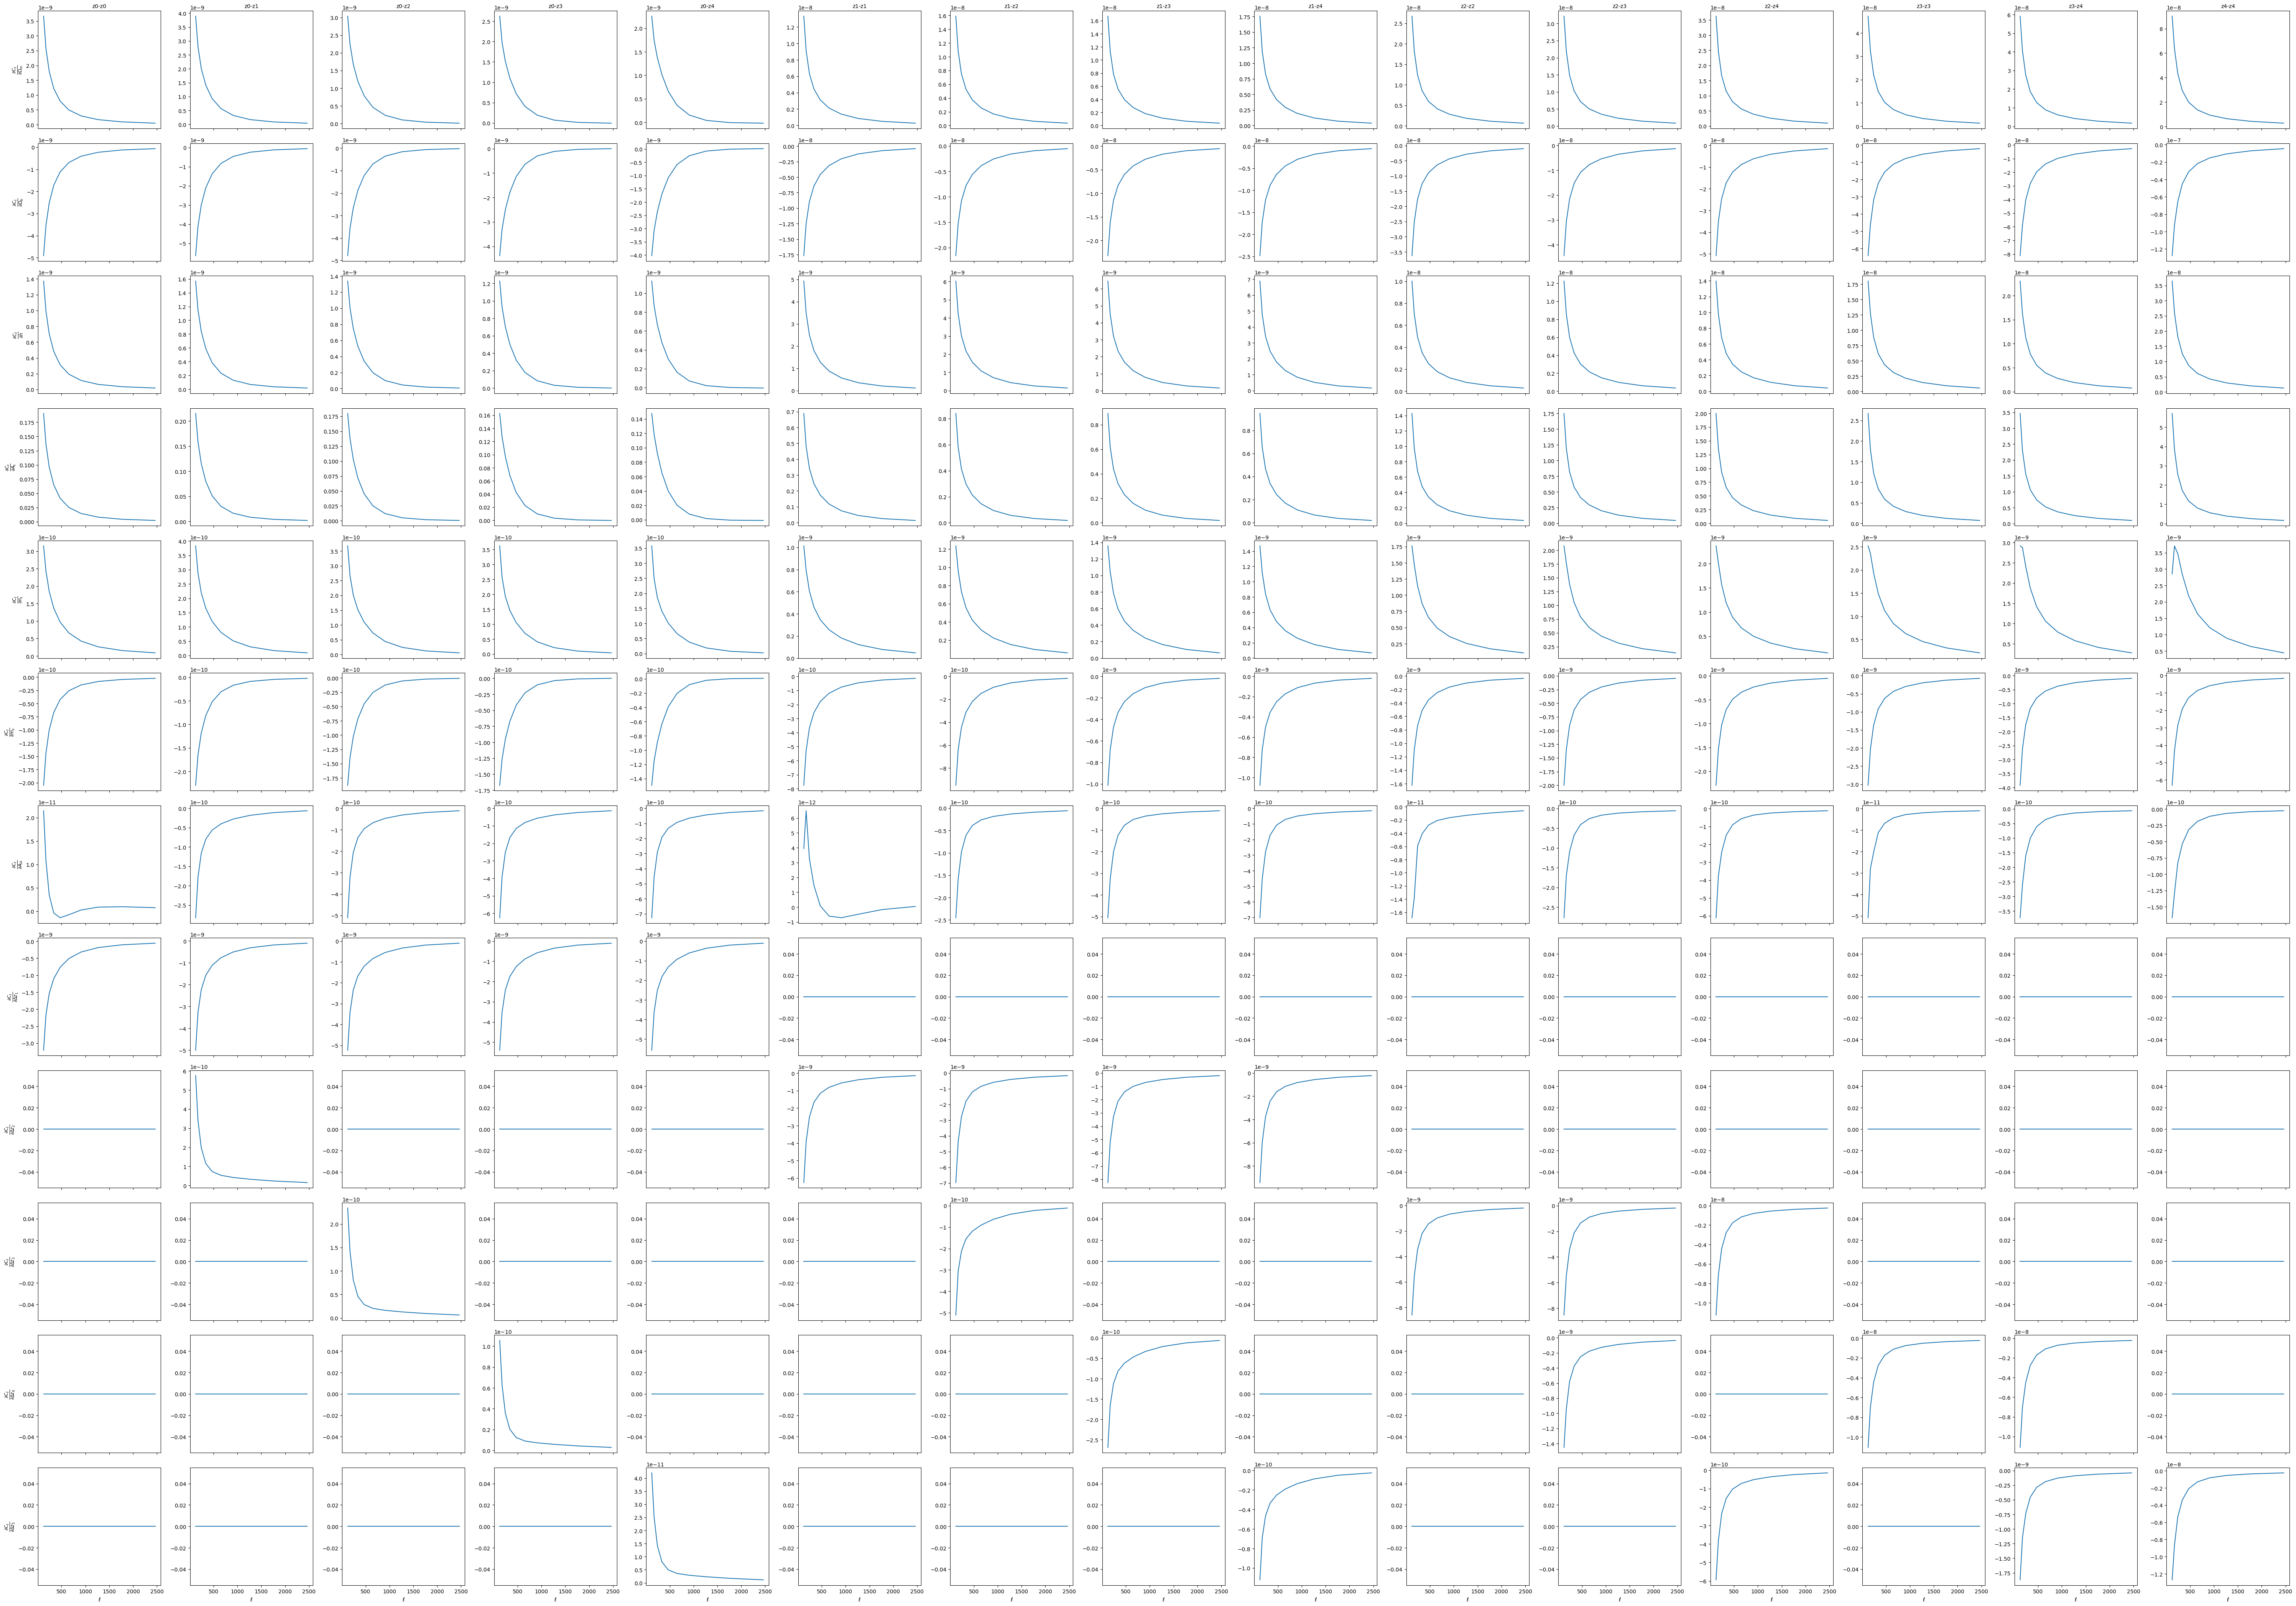

In [37]:
derivatives = fm.d_C_ell
tracers = list(fm.C_ell.keys())
param_names = fm.parameters

# derivatives shape is --> [ell x parameter x zi-zj]

n_ell, n_params, n_bins = derivatives.shape

fig, axes = plt.subplots(n_params, n_bins, figsize=(4*n_bins, 3.5*n_params), sharex=True)


for p in range(n_params):
    for b in range(n_bins):
        ax = axes[p, b] if n_params > 1 else axes[b] # axes is arraw with dimension [parameter x zi-zj] if there's more than 1 parameter (else list)

        ax.plot(ell_arr, derivatives[:, p, b]) #plot the derivative for each ell for a given parameter and bin

        if p == 0: # write bin titles in top row
            ax.set_title(tracers[b], fontsize=10)
        if b == 0: # write parameter titles in left column
            latex_name = names_to_latex(param_names[p], dollar_signs=False)
            ax.set_ylabel(fr"$\frac{{\partial C_\ell}}{{\partial {latex_name}}}$", fontsize=12)
        if p == n_params -1:
            ax.set_xlabel(r"$\ell$")
plt.tight_layout()
plt.show()
